In [42]:
# KUTUPHANELERI EKLEME

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [43]:
# VERI SETINI YUKLEME
df = pd.read_csv("reno_clio.csv")
df

,yıl,km
0,1996,220.0
1,1996,220.0
2,1996,220.0
3,1996,220.0
4,1996,220.0
...,...,...
92,2023,20.0
93,2023,42.0
94,2024,7.0
95,2024,10.0


In [44]:
# YAS HESAPLAMA
df['yas'] = 2024 - df['yıl']

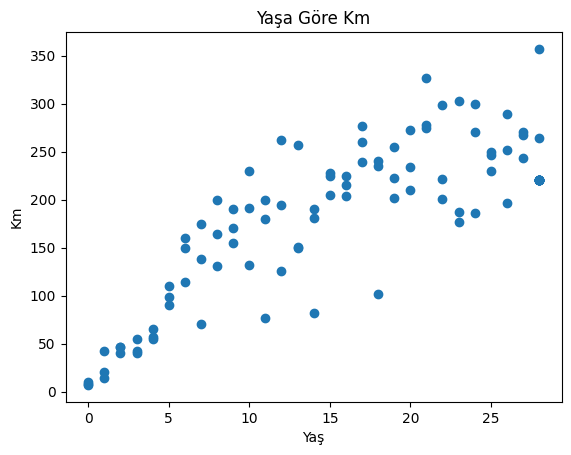

In [45]:
# YAS - KM GRAFIGI

plt.scatter(df['yas'],df['km'])
plt.xlabel('Yaş')
plt.ylabel('Km')
plt.title('Yaşa Göre Km')
plt.show()

KMeans, verileri gruplara ayırmamıza yardımcı olan bir makine öğrenmesi algoritmasıdır.

In [46]:
# KMEANS KUMELEME

kmeans = KMeans(n_clusters = 5)  # KMeans algoritmasını 5 farklı kümeye (cluster) ayırma
kmeans.fit(df[['yas', 'km']]) # fit() fonksiyonu, algoritmanın kümeleri bulması için veriyi kullanır. 
df['küme'] = kmeans.predict(df[['yas', 'km']])
df

,yıl,km,yas,küme
0,1996,220.0,28,1
1,1996,220.0,28,1
2,1996,220.0,28,1
3,1996,220.0,28,1
4,1996,220.0,28,1
...,...,...,...,...
92,2023,20.0,1,0
93,2023,42.0,1,0
94,2024,7.0,0,0
95,2024,10.0,0,0


<function matplotlib.pyplot.show(close=None, block=None)>

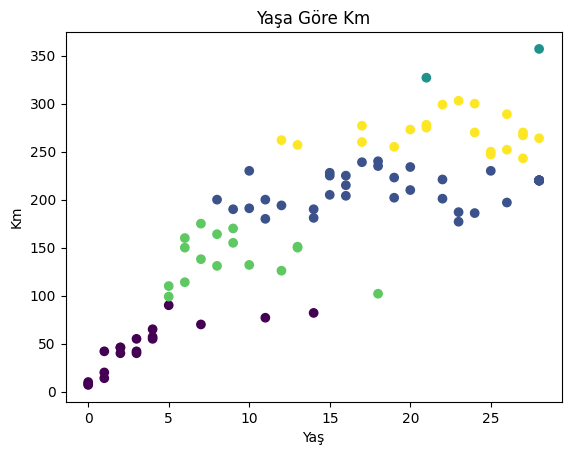

In [47]:
# KMEANS KUMELEME SONUCLARINI GORSELLESTIRME

plt.scatter(df['yas'], df['km'], c=df['küme'])
plt.xlabel('Yaş')
plt.ylabel('Km')
plt.title('Yaşa Göre Km')
plt.show

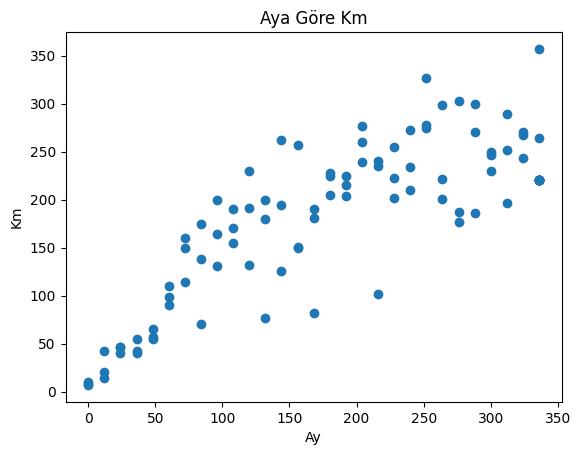

In [48]:
# AY CINSINDEN YAS HESAPLAMA

df['yas_ay'] = df['yas'] * 12 # yaş verilerini ay cinsine çevirir. 1 yıl = 12 ay olduğu için yaş değerini 12 ile çarpar.
plt.scatter(df['yas_ay'], df['km'])
plt.xlabel('Ay')
plt.ylabel('Km')
plt.title('Aya Göre Km')
plt.show()

In [49]:
# YENIDEN KMEANS KUMELEME (AY CINSINDEN)

kmeans2 = KMeans(n_clusters=5)
kmeans2.fit(df[['yas_ay', 'km']])
df['küme2'] = kmeans2.predict(df[['yas_ay', 'km']])
df

,yıl,km,yas,küme,yas_ay,küme2
0,1996,220.0,28,1,336,1
1,1996,220.0,28,1,336,1
2,1996,220.0,28,1,336,1
3,1996,220.0,28,1,336,1
4,1996,220.0,28,1,336,1
...,...,...,...,...,...,...
92,2023,20.0,1,0,12,2
93,2023,42.0,1,0,12,2
94,2024,7.0,0,0,0,2
95,2024,10.0,0,0,0,2


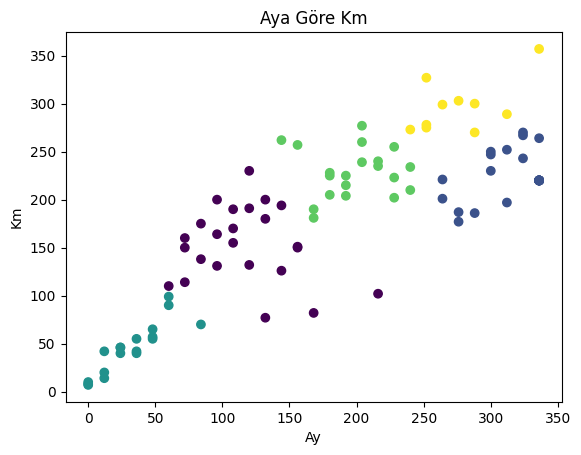

In [50]:
plt.scatter(df['yas_ay'], df['km'], c=df['küme2'])
plt.xlabel('Ay')
plt.ylabel('Km')
plt.title('Aya Göre Km')
plt.show()

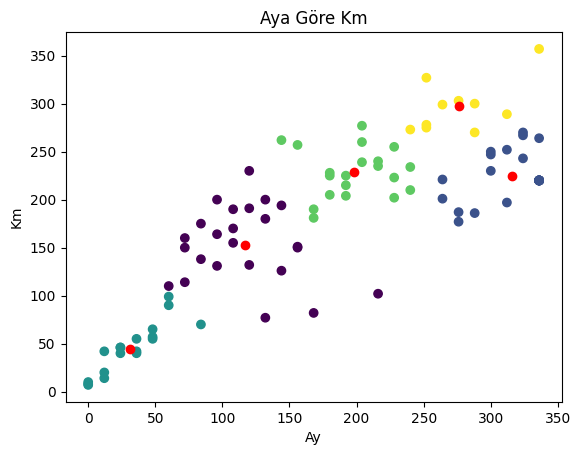

In [51]:
# KUME MERKEZLERINI GORSELLESTIRME

plt.scatter(df['yas_ay'], df['km'], c=df['küme2'])
plt.scatter(kmeans2.cluster_centers_[:,0], kmeans2.cluster_centers_[:,1], c='red')
plt.xlabel('Ay')
plt.ylabel('Km')
plt.title('Aya Göre Km')
plt.show()

[:,0] ve [:,1]: Bu ifadeler, 2D matristeki sütunları seçmek için kullanılan dilimleme (slicing) yöntemleridir.

[:,0]: X koordinatlarını alır (ilk sütun).

[:,1]: Y koordinatlarını alır (ikinci sütun).

In [52]:
df.to_csv('df.csv', index=False)

# to_csv() fonksiyonu, veriyi bir CSV dosyasına kaydeder.

# index=False ifadesi, satır numarasının dosyaya dahil edilmemesini sağlar.

In [53]:
# KUME ETIKETLERI

# cluster number 1 is çok eski
# cluster number 2 is eski
# cluster number 3 is orta
# cluster number 4 is yeni
# cluster number 5 is çok yeni

df['YeniOlmaDurumu'] = df['küme2'].replace({0: 'çok eski', 1: 'eski', 2: 'orta', 3: 'yeni', 4: 'çok yeni'})
df

,yıl,km,yas,küme,yas_ay,küme2,YeniOlmaDurumu
0,1996,220.0,28,1,336,1,eski
1,1996,220.0,28,1,336,1,eski
2,1996,220.0,28,1,336,1,eski
3,1996,220.0,28,1,336,1,eski
4,1996,220.0,28,1,336,1,eski
...,...,...,...,...,...,...,...
92,2023,20.0,1,0,12,2,orta
93,2023,42.0,1,0,12,2,orta
94,2024,7.0,0,0,0,2,orta
95,2024,10.0,0,0,0,2,orta


kümelere anlamlı etiketler ekler. Her küme numarası, anlamlı bir açıklama ile değiştirilir (örneğin, Küme 0 'çok eski' olarak adlandırılır).

In [54]:
# SONUCLARI KAYDETME

df.to_csv('df_etiketli.csv', index=False)